# 02 — EDA and MAGPIE Featurization

This notebook loads the filtered Materials Project oxygen-containing materials dataset, performs exploratory data analysis, generates MAGPIE composition descriptors, and saves the processed modeling dataset.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Locate the repository root
current_dir = Path.cwd()

if current_dir.name == "notebooks":
    project_root = current_dir.parent
else:
    project_root = current_dir

data_dir = project_root / "data"
figures_dir = project_root / "figures"

figures_dir.mkdir(parents=True, exist_ok=True)

raw_data_path = (
    data_dir
    / "zhao_nonmetal_oxide_bandgap_project.csv"
)

df = pd.read_csv(raw_data_path)

print("Raw dataset loaded successfully.")
print("Dataset shape:", df.shape)
print("Data path:", raw_data_path.resolve())
print("\nColumns:")
print(df.columns.tolist())

df.head()

Raw dataset loaded successfully.
Dataset shape: (40078, 13)
Data path: C:\Users\24250\Desktop\zhao-oxide-bandgap-project\data\zhao_nonmetal_oxide_bandgap_project.csv

Columns:
['material_id', 'formula', 'reduced_formula', 'band_gap', 'is_metal', 'formation_energy_per_atom', 'energy_above_hull', 'density', 'volume', 'nsites', 'nelements', 'elements', 'crystal_system']


,material_id,formula,reduced_formula,band_gap,is_metal,formation_energy_per_atom,energy_above_hull,density,volume,nsites,nelements,elements,crystal_system
0,mp-3346792,HCNO,HCNO,5.2381,False,-0.680053,0.000000,1.823257,235.109820,24,4,"C,H,N,O",Monoclinic
1,mp-1523737,NClO,NClO,2.0666,False,0.090138,0.159467,1.812475,239.887179,12,3,"Cl,N,O",Monoclinic
2,mp-1567687,V3OF7,V3OF7,1.3813,False,-3.022540,0.096936,3.215234,311.748264,22,3,"F,O,V",Monoclinic
3,mp-1568124,V3OF7,V3OF7,1.3700,False,-3.014306,0.105170,3.227839,310.530861,22,3,"F,O,V",Triclinic
4,mp-1568829,Fe4OF6,Fe4OF6,2.6285,False,-2.323263,0.065270,4.420859,265.461720,22,3,"F,Fe,O",Triclinic


## Exploratory Data Analysis

This section summarizes the target distribution, crystal-system sample counts, and relationships between band gap and selected numerical metadata.

In [2]:
# Summary statistics for the target and crystal-system groups

print("Band-gap summary:")
print(df["band_gap"].describe().round(3))

print("\nCrystal-system counts:")
crystal_counts = df["crystal_system"].value_counts()
print(crystal_counts)

print("\nMissing values in modeling columns:")
modeling_columns = [
    "band_gap",
    "formation_energy_per_atom",
    "energy_above_hull",
    "density",
    "volume",
    "nsites",
    "nelements",
    "crystal_system"
]

print(df[modeling_columns].isna().sum())

Band-gap summary:
count    40078.000
mean         2.079
std          1.465
min          0.100
25%          0.848
50%          1.806
75%          3.076
max          8.375
Name: band_gap, dtype: float64

Crystal-system counts:
crystal_system
Monoclinic      14447
Triclinic        9095
Orthorhombic     8160
Trigonal         2796
Tetragonal       2727
Cubic            1782
Hexagonal        1071
Name: count, dtype: int64

Missing values in modeling columns:
band_gap                     0
formation_energy_per_atom    0
energy_above_hull            0
density                      0
volume                       0
nsites                       0
nelements                    0
crystal_system               0
dtype: int64


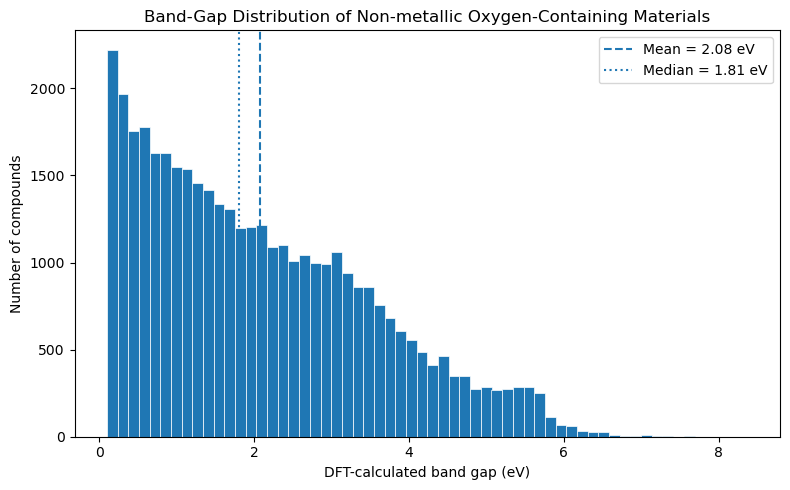

Saved: C:\Users\24250\Desktop\zhao-oxide-bandgap-project\figures\bandgap_distribution.png


In [3]:
# Band-gap distribution

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    df["band_gap"],
    bins=60,
    edgecolor="white",
    linewidth=0.5
)

mean_gap = df["band_gap"].mean()
median_gap = df["band_gap"].median()

ax.axvline(
    mean_gap,
    linestyle="--",
    linewidth=1.5,
    label=f"Mean = {mean_gap:.2f} eV"
)

ax.axvline(
    median_gap,
    linestyle=":",
    linewidth=1.5,
    label=f"Median = {median_gap:.2f} eV"
)

ax.set_xlabel("DFT-calculated band gap (eV)")
ax.set_ylabel("Number of compounds")
ax.set_title("Band-Gap Distribution of Non-metallic Oxygen-Containing Materials")
ax.legend()

fig.tight_layout()

bandgap_figure_path = figures_dir / "bandgap_distribution.png"

fig.savefig(
    bandgap_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", bandgap_figure_path.resolve())

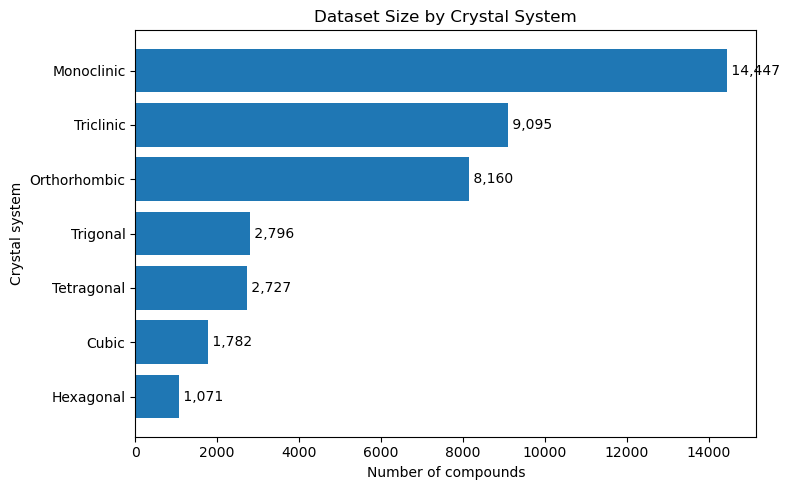

Saved: C:\Users\24250\Desktop\zhao-oxide-bandgap-project\figures\crystal_system_counts.png


In [4]:
# Crystal-system sample counts

crystal_counts_plot = (
    df["crystal_system"]
    .value_counts()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    crystal_counts_plot.index,
    crystal_counts_plot.values
)

ax.set_xlabel("Number of compounds")
ax.set_ylabel("Crystal system")
ax.set_title("Dataset Size by Crystal System")

for index, value in enumerate(crystal_counts_plot.values):
    ax.text(
        value,
        index,
        f" {value:,}",
        va="center"
    )

fig.tight_layout()

crystal_figure_path = figures_dir / "crystal_system_counts.png"

fig.savefig(
    crystal_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", crystal_figure_path.resolve())

## Correlation Analysis

This section examines linear correlations between band gap and selected stability- and structure-related metadata. Correlation does not imply causation, but it helps identify useful exploratory relationships.

Correlation matrix:


,band_gap,formation_energy_per_atom,energy_above_hull,density,volume,nsites,nelements
band_gap,1.000,-0.302,-0.267,-0.116,0.140,0.161,-0.025
formation_energy_per_atom,-0.302,1.000,0.439,-0.259,0.053,-0.003,-0.027
energy_above_hull,-0.267,0.439,1.000,-0.166,0.047,-0.053,-0.048
density,-0.116,-0.259,-0.166,1.000,-0.214,-0.252,-0.150
volume,0.140,0.053,0.047,-0.214,1.000,0.906,0.039
nsites,0.161,-0.003,-0.053,-0.252,0.906,1.000,0.102
nelements,-0.025,-0.027,-0.048,-0.150,0.039,0.102,1.000



Correlations with band gap:
formation_energy_per_atom   -0.302
energy_above_hull           -0.267
nsites                       0.161
volume                       0.140
density                     -0.116
nelements                   -0.025
Name: band_gap, dtype: float64


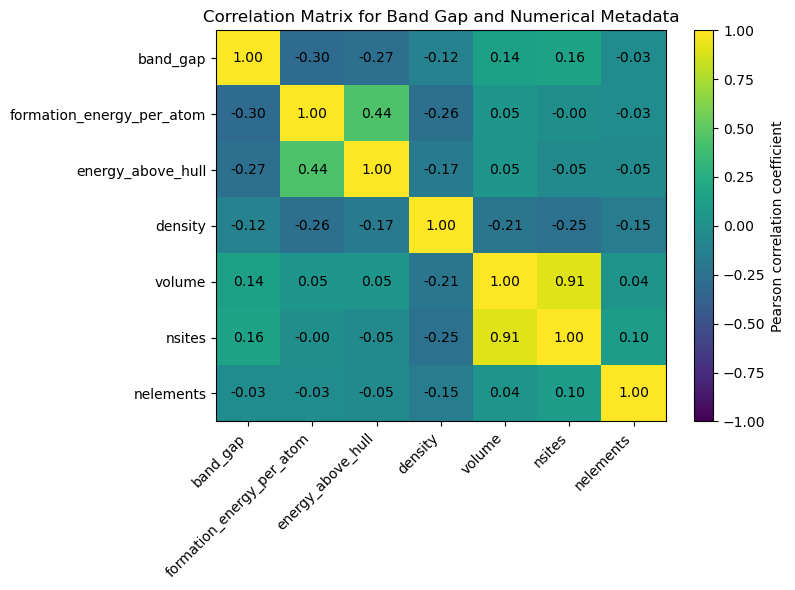

Saved: C:\Users\24250\Desktop\zhao-oxide-bandgap-project\figures\metadata_correlation_matrix.png


In [5]:
# Correlation analysis for numerical metadata

correlation_columns = [
    "band_gap",
    "formation_energy_per_atom",
    "energy_above_hull",
    "density",
    "volume",
    "nsites",
    "nelements"
]

correlation_matrix = (
    df[correlation_columns]
    .corr()
    .round(3)
)

print("Correlation matrix:")
display(correlation_matrix)

bandgap_correlations = (
    correlation_matrix["band_gap"]
    .drop("band_gap")
    .sort_values(key=abs, ascending=False)
)

print("\nCorrelations with band gap:")
print(bandgap_correlations)

fig, ax = plt.subplots(figsize=(8, 6))

image = ax.imshow(
    correlation_matrix,
    vmin=-1,
    vmax=1,
    aspect="auto"
)

ax.set_xticks(range(len(correlation_columns)))
ax.set_yticks(range(len(correlation_columns)))

ax.set_xticklabels(
    correlation_columns,
    rotation=45,
    ha="right"
)
ax.set_yticklabels(correlation_columns)

for row in range(len(correlation_columns)):
    for column in range(len(correlation_columns)):
        ax.text(
            column,
            row,
            f"{correlation_matrix.iloc[row, column]:.2f}",
            ha="center",
            va="center"
        )

ax.set_title("Correlation Matrix for Band Gap and Numerical Metadata")

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Pearson correlation coefficient")

fig.tight_layout()

correlation_figure_path = (
    figures_dir / "metadata_correlation_matrix.png"
)

fig.savefig(
    correlation_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", correlation_figure_path.resolve())

### Correlation Finding

Formation energy per atom has the strongest linear association with band gap among the selected metadata features, with a Pearson correlation coefficient of approximately -0.302. Energy above the convex hull also shows a moderate negative correlation of approximately -0.267. These relationships suggest that stability-related variables may contain useful predictive information, although correlation alone does not establish causation.

Volume and number of sites are strongly correlated with each other, with a coefficient of approximately 0.906, indicating substantial redundancy between these two structural-size descriptors. No individual metadata feature has a strong linear relationship with band gap, which motivates using nonlinear models and composition-based MAGPIE descriptors in the subsequent analysis.

In [6]:
from pathlib import Path
import warnings

import pandas as pd
from matminer.featurizers.conversions import StrToComposition
from matminer.featurizers.composition import ElementProperty


processed_data_path = (
    data_dir
    / "zhao_nonmetal_oxide_bandgap_magpie_project.csv"
)


# ------------------------------------------------------------
# Use the cached MAGPIE dataset when available
# ------------------------------------------------------------
if processed_data_path.exists():

    df_processed = pd.read_csv(
        processed_data_path
    )

    print("Loaded cached MAGPIE dataset.")

    # Older cached versions may not contain reduced_formula.
    # Restore it from the raw dataset rather than recalculating it.
    if "reduced_formula" not in df_processed.columns:

        reduced_formula_lookup = (
            df[
                [
                    "material_id",
                    "reduced_formula"
                ]
            ]
            .drop_duplicates(
                subset="material_id"
            )
        )

        df_processed = df_processed.merge(
            reduced_formula_lookup,
            on="material_id",
            how="left",
            validate="one_to_one"
        )

        df_processed.to_csv(
            processed_data_path,
            index=False
        )

        print(
            "Restored reduced_formula "
            "from the raw dataset."
        )


# ------------------------------------------------------------
# Generate MAGPIE descriptors when no cache is available
# ------------------------------------------------------------
else:

    print("No cached MAGPIE dataset found.")
    print("Generating MAGPIE descriptors...")

    df_processed = df.copy()

    converter = StrToComposition(
        target_col_id="composition"
    )

    magpie_featurizer = (
        ElementProperty.from_preset(
            "magpie"
        )
    )

    # Suppress only pymatgen's harmless helium
    # electronegativity warning.
    with warnings.catch_warnings():

        warnings.filterwarnings(
            "ignore",
            message=(
                "No Pauling electronegativity for He.*"
            ),
            category=UserWarning
        )

        df_processed = (
            converter.featurize_dataframe(
                df_processed,
                col_id="formula",
                ignore_errors=False
            )
        )

        df_processed = (
            magpie_featurizer.featurize_dataframe(
                df_processed,
                col_id="composition",
                ignore_errors=True
            )
        )

    df_processed = df_processed.drop(
        columns=["composition"]
    )

    df_processed.to_csv(
        processed_data_path,
        index=False
    )

    print("MAGPIE featurization complete.")


# ------------------------------------------------------------
# Validate and report the processed dataset
# ------------------------------------------------------------
magpie_cols = [
    column
    for column in df_processed.columns
    if "MagpieData" in column
]

required_processed_columns = [
    "formula",
    "reduced_formula",
    "band_gap",
    "crystal_system"
]

missing_processed_columns = [
    column
    for column in required_processed_columns
    if column not in df_processed.columns
]

if missing_processed_columns:
    raise ValueError(
        "Processed dataset is missing required columns: "
        f"{missing_processed_columns}"
    )

print("Processed dataset shape:", df_processed.shape)
print("Number of MAGPIE features:", len(magpie_cols))
print(
    "Missing reduced formulas:",
    df_processed["reduced_formula"].isna().sum()
)
print(
    "Unique reduced formulas:",
    df_processed["reduced_formula"].nunique()
)
print("Saved to:", processed_data_path.resolve())

print("\nFirst five MAGPIE feature names:")
print(magpie_cols[:5])

display(
    df_processed[
        [
            "formula",
            "reduced_formula"
        ]
    ].head()
)

Loaded cached MAGPIE dataset.
Processed dataset shape: (40078, 147)
Number of MAGPIE features: 132
Missing reduced formulas: 0
Unique reduced formulas: 22816
Saved to: C:\Users\24250\Desktop\zhao-oxide-bandgap-project\data\zhao_nonmetal_oxide_bandgap_magpie_project.csv

First five MAGPIE feature names:
['MagpieData minimum Number', 'MagpieData maximum Number', 'MagpieData range Number', 'MagpieData mean Number', 'MagpieData avg_dev Number']


,formula,reduced_formula
0,HCNO,HCNO
1,NClO,NClO
2,V3OF7,V3OF7
3,V3OF7,V3OF7
4,Fe4OF6,Fe4OF6
